In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
from datetime import datetime
import re

# Updated imports - Add Folium for better maps
import folium
from folium import plugins
import branca.colormap as cm
import keras
from keras import layers
import tensorflow as tf  # Still need TF for some backend operations
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import os
import pickle
import random
from datetime import datetime, timedelta

In [6]:
class HurricaneSimulation:
    def __init__(self, hurdat2_file, wind_farm_lat, wind_farm_lon, turbine_height=150, turbines_coord=None, windfarm_coord=None, output_dir=None):
        self.hurdat2_file = hurdat2_file
        self.wind_farm_lat = wind_farm_lat
        self.wind_farm_lon = wind_farm_lon
        self.turbine_height = turbine_height
        self.turbines_coord = turbines_coord
        self.windfarm_coord = windfarm_coord
        self.hurdat_df = self.parse_hurdat2()
        
        # Set output directory
        if output_dir:
            self.output_dir = output_dir
            os.makedirs(self.output_dir, exist_ok=True)
        else:
            self.output_dir = "/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Response_hurricane/Output_maps_lite"
            os.makedirs(self.output_dir, exist_ok=True)
        
        # Load coordinate data if provided
        self.turbine_locations = self.load_turbine_coordinates() if turbines_coord else None
        self.windfarm_polygon = self.load_windfarm_coordinates() if windfarm_coord else None
    
    def load_turbine_coordinates(self):
        """Load turbine coordinates from CSV file."""
        try:
            turbines = pd.read_csv(self.turbines_coord, header=None, names=['longitude', 'latitude'])
            print(f"Loaded {len(turbines)} turbine locations")
            return turbines
        except Exception as e:
            print(f"Error loading turbine coordinates: {e}")
            return None
    
    def load_windfarm_coordinates(self):
        """Load wind farm polygon coordinates from text file."""
        try:
            with open(self.windfarm_coord, 'r') as f:
                content = f.read().strip()
            
            # Extract coordinates from POLYGON format
            if content.startswith('POLYGON'):
                # Remove 'POLYGON ((' and '))'
                coords_str = content.replace('POLYGON ((', '').replace('))', '')
                coord_pairs = coords_str.split(', ')
                
                coordinates = []
                for pair in coord_pairs:
                    lon, lat = pair.split(' ')
                    coordinates.append([float(lat), float(lon)])  # Folium uses [lat, lon]
                
                print(f"Loaded wind farm polygon with {len(coordinates)} points")
                return coordinates
            else:
                print("Wind farm coordinate file format not recognized")
                return None
        except Exception as e:
            print(f"Error loading wind farm coordinates: {e}")
            return None

    def parse_hurdat2(self):
        with open(self.hurdat2_file, 'r') as f:
            file_content = f.read()
        
        lines = file_content.strip().split('\n')
        data = []
        current_header = None
        
        for line in lines:
            if re.match(r'^[A-Z]{2}\d{6}', line):
                parts = line.split(',')
                basin_id = parts[0].strip()
                basin = basin_id[:2]
                cyclone_number = basin_id[2:4]
                year = basin_id[4:8]
                name = parts[1].strip()
                num_entries = int(parts[2].strip())
                current_header = {
                    'basin': basin,
                    'cyclone_number': cyclone_number,
                    'year': year,
                    'full_id': basin_id,
                    'name': name,
                    'num_entries': num_entries
                }
            else:
                if current_header:
                    parts = line.split(',')
                    date_str = parts[0].strip()
                    time_str = parts[1].strip()
                    year = int(date_str[0:4])
                    month = int(date_str[4:6])
                    day = int(date_str[6:8])
                    hour = int(time_str[0:2]) if time_str else 0
                    minute = int(time_str[2:4]) if len(time_str) >= 4 else 0
                    record_id = parts[2].strip()  # Fixed: was parts[2.strip()]
                    status = parts[3].strip()
                    lat_str = parts[4].strip()
                    lon_str = parts[5].strip()
                    lat = float(lat_str[:-1]) * (1 if lat_str[-1] == 'N' else -1)
                    lon = float(lon_str[:-1]) * (-1 if lon_str[-1] == 'W' else 1)
                    max_wind = int(parts[6].strip()) if parts[6].strip() not in ['-999', ''] else None
                    min_pressure = int(parts[7].strip()) if parts[7].strip() not in ['-999', ''] else None
                    ne_34kt = int(parts[8].strip()) if len(parts) > 8 and parts[8].strip() not in ['-999', ''] else None
                    se_34kt = int(parts[9].strip()) if len(parts) > 9 and parts[9].strip() not in ['-999', ''] else None
                    sw_34kt = int(parts[10].strip()) if len(parts) > 10 and parts[10].strip() not in ['-999', ''] else None
                    nw_34kt = int(parts[11].strip()) if len(parts) > 11 and parts[11].strip() not in ['-999', ''] else None
                    ne_50kt = int(parts[12].strip()) if len(parts) > 12 and parts[12].strip() not in ['-999', ''] else None
                    se_50kt = int(parts[13].strip()) if len(parts) > 13 and parts[13].strip() not in ['-999', ''] else None
                    sw_50kt = int(parts[14].strip()) if len(parts) > 14 and parts[14].strip() not in ['-999', ''] else None
                    nw_50kt = int(parts[15].strip()) if len(parts) > 15 and parts[15].strip() not in ['-999', ''] else None
                    ne_64kt = int(parts[16].strip()) if len(parts) > 16 and parts[16].strip() not in ['-999', ''] else None
                    se_64kt = int(parts[17].strip()) if len(parts) > 17 and parts[17].strip() not in ['-999', ''] else None
                    sw_64kt = int(parts[18].strip()) if len(parts) > 18 and parts[18].strip() not in ['-999', ''] else None
                    nw_64kt = int(parts[19].strip()) if len(parts) > 19 and parts[19].strip() not in ['-999', ''] else None
                    rmw = int(parts[20].strip()) if len(parts) > 20 and parts[20].strip() not in ['-999', ''] else None
                    data.append({
                        'basin': current_header['basin'],
                        'cyclone_number': current_header['cyclone_number'],
                        'full_id': current_header['full_id'],
                        'storm_name': current_header['name'],
                        'year': year,
                        'month': month,
                        'day': day,
                        'hour': hour,
                        'minute': minute,
                        'record_id': record_id,
                        'status': status,
                        'latitude': lat,
                        'longitude': lon,
                        'max_wind': max_wind,
                        'min_pressure': min_pressure,
                        'ne_34kt_radius': ne_34kt,
                        'se_34kt_radius': se_34kt,
                        'sw_34kt_radius': sw_34kt,
                        'nw_34kt_radius': nw_34kt,
                        'ne_50kt_radius': ne_50kt,
                        'se_50kt_radius': se_50kt,
                        'sw_50kt_radius': sw_50kt,
                        'nw_50kt_radius': nw_50kt,
                        'ne_64kt_radius': ne_64kt,
                        'se_64kt_radius': se_64kt,
                        'sw_64kt_radius': sw_64kt,
                        'nw_64kt_radius': nw_64kt,
                        'radius_max_wind': rmw
                    })
        
        df = pd.DataFrame(data)
        df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
        return df
    
    def select_hurricane(self, storm_id):
        hurricane_data = self.hurdat_df[self.hurdat_df['full_id'] == storm_id]
        if not hurricane_data.empty:
            storm_name = hurricane_data['storm_name'].iloc[0]
            print(f"Selected Hurricane: {storm_id}, {storm_name}")
        return hurricane_data
    
    def filter_by_date(self, hurricane_data, month, day):
        return hurricane_data[(hurricane_data['month'] == month) & (hurricane_data['day'] == day)]
    
    def haversine_distance(self, lat1, lon1, lat2, lon2):
        from math import radians, sin, cos, sqrt, atan2
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        distance = 6371 * c  # Earth radius in km
        return distance
    
    def calculate_distances(self, hurricane_data):
        return hurricane_data.apply(lambda row: self.haversine_distance(self.wind_farm_lat, self.wind_farm_lon, row['latitude'], row['longitude']), axis=1)
    
    def holland_wind_profile(self, r, vmax, rmax, B=1.5, latitude=None):
        """
        Holland wind profile model that matches Hurricane V1 implementation.
        
        Physics:
        - Hurricane eye (r ≈ 0): Very low wind speeds
        - Eyewall (r = rmax): Maximum wind speeds (vmax)  
        - Outer bands (r > rmax): Decreasing wind speeds with distance
        
        Parameters:
        -----------
        r : float or array
            Distance(s) from hurricane center in km
        vmax : float
            Maximum wind speed at the eyewall in knots
        rmax : float
            Radius of maximum wind (eyewall radius) in km
        B : float
            Holland B parameter (shape parameter, typically 1.0-2.5)
        latitude : float, optional
            Latitude for Coriolis parameter calculation
            
        Returns:
        --------
        float or array
            Wind speed at distance r (in same units as vmax)
        """
        # Handle single values and arrays consistently
        if np.isscalar(r):
            if r == 0:
                return vmax
            return vmax * (rmax/r)**B * np.exp(1 - (rmax/r)**B)
        
        # For arrays, vectorized calculation
        r = np.asarray(r)
        wind_speeds = np.zeros_like(r, dtype=float)
        
        # Handle center points (r ≈ 0)
        center_mask = r < 0.001
        wind_speeds[center_mask] = vmax
        
        # Handle non-center points
        non_center_mask = ~center_mask
        r_non_center = r[non_center_mask]
        
        if len(r_non_center) > 0:
            wind_speeds[non_center_mask] = vmax * (rmax/r_non_center)**B * np.exp(1 - (rmax/r_non_center)**B)
        
        return wind_speeds
    
    def calculate_wind_direction(self, lat1, lon1, lat2, lon2):
        from math import atan2, degrees
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        angle = atan2(dlat, dlon)
        bearing = (degrees(angle) + 360) % 360
        return bearing
    
    def adjust_wind_speed_to_height(self, wind_speed, reference_height=10, alpha=0.14):
        """
        Adjust wind speed to the turbine height using the power law.
        :param wind_speed: Wind speed at the reference height (typically 10m).
        :param reference_height: The height at which the wind speed is measured.
        :param alpha: Wind shear exponent (typically 0.14 for offshore locations).
        :return: Adjusted wind speed at the turbine height.
        """
        return wind_speed * (self.turbine_height / reference_height) ** alpha
    
    def estimate_wind_speed(self, hurricane_data, distances):
        if not distances.empty:
            closest_index = distances.idxmin()
            closest_record = hurricane_data.loc[closest_index]
            vmax = closest_record['max_wind']  # knots
            distance_km = distances[closest_index]
            rmax = 50  # typical value, can be adjusted
            wind_speed = self.holland_wind_profile(distance_km, vmax, rmax)
            wind_speed_adjusted = self.adjust_wind_speed_to_height(wind_speed)
            wind_direction = self.calculate_wind_direction(closest_record['latitude'], closest_record['longitude'], self.wind_farm_lat, self.wind_farm_lon)
            return wind_speed_adjusted, distance_km, vmax, wind_direction
        else:
            return None, None, None, None
    
    def plot_hurricane_tracks(self, hurricane_data, title='Hurricane Tracks'):
        fig = plt.figure(figsize=(15, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.add_feature(cfeature.STATES, linestyle=':')
        ax.set_extent([-100, -50, 10, 50], crs=ccrs.PlateCarree())

        # Add OpenStreetMap base map
        osm_tiles = cimgt.OSM()
        ax.add_image(osm_tiles, 8)

        # Plot hurricane path
        plt.plot(hurricane_data['longitude'], hurricane_data['latitude'],
                 '-o', markersize=4, label=hurricane_data['storm_name'].iloc[0], transform=ccrs.PlateCarree())

        # Color points by intensity
        scatter = plt.scatter(hurricane_data['longitude'], hurricane_data['latitude'], 
                              c=hurricane_data['max_wind'], cmap='YlOrRd', 
                              transform=ccrs.PlateCarree())

        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Maximum Wind Speed (knots)')

        plt.title(title)
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.show()
    
    def plot_hurricane_tracks_folium(self, hurricane_data, title='Hurricane Tracks'):
        """
        Create an interactive hurricane track visualization using Folium with realistic maps.
        """
        # Calculate map center
        center_lat = (hurricane_data['latitude'].min() + hurricane_data['latitude'].max()) / 2
        center_lon = (hurricane_data['longitude'].min() + hurricane_data['longitude'].max()) / 2
        
        # Create folium map with higher zoom and allow higher max zoom for HD tiles
        m = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=8,  # Increased from 6 for higher detail
            tiles=None
        )
        # Add high-res tile layers (set max_zoom higher)
        folium.TileLayer(
            tiles='OpenStreetMap',
            name='OpenStreetMap',
            overlay=False,
            control=True,
            max_zoom=19  # Allow higher zoom levels
        ).add_to(m)
        folium.TileLayer(
            tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
            attr='Esri',
            name='Satellite',
            overlay=False,
            control=True,
            max_zoom=19  # Allow higher zoom levels
        ).add_to(m)
        folium.TileLayer(
            tiles='CartoDB positron',
            name='Light',
            overlay=False,
            control=True,
            max_zoom=19
        ).add_to(m)
        
        # Add wind farm polygon if available
        if self.windfarm_polygon:
            folium.Polygon(
                locations=self.windfarm_polygon,
                color='green',
                weight=3,
                fillColor='lightgreen',
                fillOpacity=0.3,
                popup='Wind Farm Boundary',
                tooltip='Wind Farm Area'
            ).add_to(m)
        
        # Add turbine locations if available
        if self.turbine_locations is not None:
            for idx, turbine in self.turbine_locations.iterrows():
                folium.CircleMarker(
                    location=[turbine['latitude'], turbine['longitude']],
                    radius=3,
                    popup=f'Turbine {idx+1}',
                    tooltip=f'Turbine {idx+1}',
                    color='darkgreen',
                    weight=1,
                    fillColor='white',
                    fillOpacity=0.8
                ).add_to(m)
        
        # Create color map for wind intensity (convert to m/s)
        colormap = cm.LinearColormap(
            colors=['blue', 'green', 'yellow', 'orange', 'red', 'darkred'],
            vmin=hurricane_data['max_wind'].min() * 0.514,
            vmax=hurricane_data['max_wind'].max() * 0.514,
            caption='Maximum Wind Speed (m/s)'
        )
        
        # Add hurricane track points
        track_points = []
        for idx, row in hurricane_data.iterrows():
            lat, lon = row['latitude'], row['longitude']
            wind_speed = row['max_wind']
            datetime_str = row['datetime'].strftime('%Y-%m-%d %H:%M')
            
            # Color based on wind intensity
            color = colormap(wind_speed)
            
            # Create popup with hurricane info
            popup_text = f"""
            <b style=\"font-size: 13px;\">{row['storm_name']}</b><br>
            <span style=\"font-size: 13px;\">Date: {datetime_str}</span><br>
            <span style=\"font-size: 13px;\">Max Wind: {wind_speed * 0.514:.1f} m/s</span><br>
            <span style=\"font-size: 13px;\">Category: {self.classify_hurricane(wind_speed)}</span><br>
            <span style=\"font-size: 13px;\">Pressure: {row.get('min_pressure', 'N/A')} mb</span><br>
            <span style=\"font-size: 13px;\">Distance to Farm: {self.haversine_distance(self.wind_farm_lat, self.wind_farm_lon, lat, lon):.1f} km</span>
            """
            
            folium.CircleMarker(
                location=[lat, lon],
                radius=6,
                popup=folium.Popup(popup_text, max_width=900),  # Make popup much wider
                color='white',
                weight=1,
                fillColor=color,
                fillOpacity=0.8,
                tooltip=f"{datetime_str}: {wind_speed * 0.514:.1f} m/s"
            ).add_to(m)
            
            track_points.append([lat, lon])
        
        # Add hurricane track line
        folium.PolyLine(
            locations=track_points,
            color='red',
            weight=3,
            opacity=0.8,
            popup=f"Hurricane {hurricane_data['storm_name'].iloc[0]} Track"
        ).add_to(m)
        
        # Add distance circles around wind farm
        for radius_km in [100, 250, 500]:
            folium.Circle(
                location=[self.wind_farm_lat, self.wind_farm_lon],
                radius=radius_km * 1000,  # Convert to meters
                popup=f'{radius_km} km radius',
                color='blue',
                weight=1,
                fillOpacity=0.1
            ).add_to(m)
        
        # Add colormap to map
        colormap.add_to(m)
        
        # Add layer control
        folium.LayerControl().add_to(m)
        
        # Add title
        title_html = f'''
        <h3 align="center" style="font-size:16px; color:white; background-color:rgba(0,0,0,0.7); padding:10px; margin:10px; border-radius:5px; text-shadow: 2px 2px 4px rgba(0,0,0,0.8);"><b>{title}</b></h3>
        '''
        m.get_root().html.add_child(folium.Element(title_html))
        
        return m
    
    def plot_wind_field(self, hurricane_data, rmax=50, B=1.5, show_vectors=True):
        """
        Enhanced wind field plotting with vectorized calculation and wind direction vectors.
        
        Parameters:
        -----------
        hurricane_data : DataFrame or Series
            Hurricane data containing latitude, longitude, and max_wind
            Can be a DataFrame or a Series (single row)
        rmax : float
            Radius of maximum wind in km
        B : float
            Holland B parameter (shape parameter)
        show_vectors : bool
            Whether to show wind direction vectors
        """
        # Check if hurricane_data is a Series (single row) or DataFrame
        if isinstance(hurricane_data, pd.Series):
            lat_center = hurricane_data['latitude']
            lon_center = hurricane_data['longitude']
            vmax = hurricane_data['max_wind']  # knots
        else:
            lat_center = hurricane_data['latitude'].iloc[0]
            lon_center = hurricane_data['longitude'].iloc[0]
            vmax = hurricane_data['max_wind'].iloc[0]  # knots
        
        # Create grid (vectorized)
        resolution = 100  # Reduced from 200 for performance
        lat_range = np.linspace(lat_center - 10, lat_center + 10, resolution)
        lon_range = np.linspace(lon_center - 10, lon_center + 10, resolution)
        
        lon_grid, lat_grid = np.meshgrid(lon_range, lat_range)
        
        # Calculate distances vectorized using haversine formula
        lat1, lon1 = np.radians(lat_center), np.radians(lon_center)
        lat2, lon2 = np.radians(lat_grid), np.radians(lon_grid)
        
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
        distances = 6371 * c  # Earth radius in km
        
        # Calculate wind speeds using vectorized Holland model
        wind_speeds = np.zeros_like(distances)
        
        # Handle the central point separately to avoid division by zero
        center_mask = distances < 0.001
        non_center_mask = ~center_mask
        
        wind_speeds[center_mask] = vmax
        # Improved Holland model with vectorized calculation
        wind_speeds[non_center_mask] = vmax * (rmax/distances[non_center_mask])**B * np.exp(1 - (rmax/distances[non_center_mask])**B)
        
        # Calculate u and v components for wind vectors
        # For cyclonic flow in Northern Hemisphere (counter-clockwise)
        u = -np.sin(np.arctan2(lat_grid - lat_center, lon_grid - lon_center)) * wind_speeds
        v = np.cos(np.arctan2(lat_grid - lat_center, lon_grid - lon_center)) * wind_speeds
        
        # Create plot
        fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
        
        # Add map features
        ax.coastlines(resolution='10m')
        ax.add_feature(cfeature.STATES.with_scale('10m'), linestyle=':', alpha=0.5)
        ax.add_feature(cfeature.OCEAN)
        ax.add_feature(cfeature.LAND, edgecolor='black')
        
        # Add OpenStreetMap base map
        osm_tiles = cimgt.OSM()
        ax.add_image(osm_tiles, 8)
        
        # Plot contour fill
        levels = np.linspace(0, min(wind_speeds.max(), vmax*1.2), 20)
        contour = ax.contourf(lon_grid, lat_grid, wind_speeds, levels=levels, 
                             cmap='YlOrRd', transform=ccrs.PlateCarree(), alpha=0.7)
        
        # Add hurricane location marker
        ax.plot(lon_center, lat_center, 'o',
                color='blue', markersize=8, transform=ccrs.PlateCarree(), 
                label='Hurricane Center')
        
        # Mark wind farm
        ax.plot(self.wind_farm_lon, self.wind_farm_lat, 'D',
                color='red', markersize=6, transform=ccrs.PlateCarree(),
                label='Wind Farm')
        
        # Add wind vectors if requested
        if show_vectors:
            # Subsample the grid for better visualization
            skip = 5
            ax.quiver(lon_grid[::skip, ::skip], lat_grid[::skip, ::skip],
                     u[::skip, ::skip], v[::skip, ::skip],
                     transform=ccrs.PlateCarree(), scale=1000,
                     color='gray', alpha=0.6, width=0.003)
        
        # Add colorbar
        cbar = plt.colorbar(contour, ax=ax, shrink=0.8)
        cbar.set_label('Wind Speed (knots)')
        
        # Add labels and legend
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.set_title(f'Hurricane Wind Field - Max Wind: {vmax} knots')
        ax.legend(loc='upper right')
        
        # Add grid reference
        gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        
        plt.show()
        
        return wind_speeds, u, v

    def plot_wind_field_folium(self, hurricane_data, rmax=50, B=1.5):
        """
        Create an interactive wind field visualization using Folium with corrected wind physics.
        """
        # Check if hurricane_data is a Series (single row) or DataFrame
        if isinstance(hurricane_data, pd.Series):
            lat_center = hurricane_data['latitude']
            lon_center = hurricane_data['longitude']
            vmax = hurricane_data['max_wind']  # knots
            datetime_str = hurricane_data['datetime'].strftime('%Y-%m-%d %H:%M')
        else:
            lat_center = hurricane_data['latitude'].iloc[0]
            lon_center = hurricane_data['longitude'].iloc[0]
            vmax = hurricane_data['max_wind'].iloc[0]  # knots
            datetime_str = hurricane_data['datetime'].iloc[0].strftime('%Y-%m-%d %H:%M')
        
        # Create folium map centered on hurricane
        m = folium.Map(
            location=[lat_center, lon_center],
            zoom_start=8,  # Increased from 7 for higher detail
            tiles=None
        )
        
        folium.TileLayer(
            tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
            attr='Esri',
            name='Satellite',
            overlay=False,
            control=True,
            max_zoom=19
        ).add_to(m)
        
        folium.TileLayer(
            tiles='OpenStreetMap',
            name='OpenStreetMap',
            overlay=False,
            control=True,
            max_zoom=19
        ).add_to(m)
        
        # Add wind farm polygon if available
        if self.windfarm_polygon:
            folium.Polygon(
                locations=self.windfarm_polygon,
                color='green',
                weight=3,
                fillColor='lightgreen',
                fillOpacity=0.3,
                popup='Wind Farm Boundary',
                tooltip='Wind Farm Area'
            ).add_to(m)
        
        # Add turbine locations if available
        if self.turbine_locations is not None:
            for idx, turbine in self.turbine_locations.iterrows():
                # Calculate wind speed at this turbine location
                distance_to_turbine = self.haversine_distance(lat_center, lon_center, turbine['latitude'], turbine['longitude'])
                wind_at_turbine = self.holland_wind_profile(distance_to_turbine, vmax, rmax, B)
                wind_at_turbine_adjusted = self.adjust_wind_speed_to_height(wind_at_turbine)
                
                # Color code turbines based on wind speed (convert to m/s for comparison)
                wind_at_turbine_ms = wind_at_turbine_adjusted * 0.514
                if wind_at_turbine_ms > 25:  # Above cut-out speed (48.6 knots = 25 m/s)
                    turbine_color = 'red'
                    turbine_icon = 'exclamation-triangle'
                elif wind_at_turbine_ms > 12.9:  # High wind (25 knots = 12.9 m/s)
                    turbine_color = 'orange'
                    turbine_icon = 'flash'
                else:  # Normal operation
                    turbine_color = 'green'
                    turbine_icon = 'flash'
                
                folium.Marker(
                    location=[turbine['latitude'], turbine['longitude']],
                    popup=folium.Popup(f'''
                    <b style="font-size: 13px;">Turbine {idx+1}</b><br>
                    <span style="font-size: 13px;">Wind Speed: {wind_at_turbine_adjusted * 0.514:.1f} m/s</span><br>
                    <span style="font-size: 13px;">Distance from Hurricane: {distance_to_turbine:.1f} km</span>
                    ''', max_width=700),  # Make popup much wider
                    tooltip=f'Turbine {idx+1}: {wind_at_turbine_adjusted * 0.514:.1f} m/s',
                    icon=folium.Icon(color=turbine_color, icon=turbine_icon, prefix='fa', size=(8, 8))
                ).add_to(m)
        
        # Add hurricane center with correct information
        folium.Marker(
            location=[lat_center, lon_center],
            popup=folium.Popup(f'''
            <b style="font-size: 13px;">Hurricane Eye</b><br>
            <span style="font-size: 13px;">Time: {datetime_str}</span><br>
            <span style="font-size: 13px;">Eye Wind Speed: ~0-10 m/s</span><br>
            <span style="font-size: 13px;">Eyewall Max Wind: {vmax * 0.514:.1f} m/s</span><br>
            <span style="font-size: 13px;">Category: {self.classify_hurricane(vmax)}</span>
            ''', max_width=700),  # Make popup much wider
            tooltip=f'Hurricane Eye (Max wind at eyewall: {vmax * 0.514:.1f} m/s)',
            icon=folium.Icon(color='darkblue', icon='eye', prefix='fa')
        ).add_to(m)
        
        # Add eyewall marker
        folium.Circle(
            location=[lat_center, lon_center],
            radius=rmax * 1000,  # Convert km to meters
            color='red',
            weight=3,
            fillColor='red',
            fillOpacity=0.3,
            popup=f'Eyewall - Maximum winds: {vmax * 0.514:.1f} m/s',
            tooltip=f'Eyewall (radius: {rmax} km)'
        ).add_to(m)
        
        # Add concentric wind speed circles with corrected labels
        wind_radii = [rmax * 2, rmax * 4, rmax * 6, rmax * 8]  # Multiples of RMW
        colors = ['orange', 'yellow', 'lightblue', 'lightgray']
        
        for i, radius_km in enumerate(wind_radii):
            wind_speed = self.holland_wind_profile(radius_km, vmax, rmax, B)
            
            folium.Circle(
                location=[lat_center, lon_center],
                radius=radius_km * 1000,  # Convert to meters
                color=colors[i],
                weight=2,
                fillColor=colors[i],
                fillOpacity=0.1,
                popup=f'Wind at {radius_km:.0f} km: {wind_speed * 0.514:.1f} m/s',
                tooltip=f'{radius_km:.0f} km: {wind_speed * 0.514:.1f} m/s'
            ).add_to(m)
        
        # Add layer control positioned at bottom right
        folium.LayerControl(position='bottomright').add_to(m)
        
        # Add title
        title_html = f'''
        <h3 align="center" style="font-size:16px; color:white; background-color:rgba(0,0,0,0.7); padding:10px; margin:10px; border-radius:5px; text-shadow: 2px 2px 4px rgba(0,0,0,0.8);"><b>Hurricane Wind Field - Eyewall Max: {vmax * 0.514:.1f} m/s</b></h3>
        <p align="center" style="font-size:12px; color:white; background-color:rgba(0,0,0,0.7); padding:5px; margin:5px; border-radius:3px;">
        Note: Eye has very low winds, maximum winds occur at the eyewall (red circle)
        </p>
        '''
        m.get_root().html.add_child(folium.Element(title_html))
        
        return m

    def estimate_wind_speed_over_time(self, hurricane_data):
        wind_speeds = []
        distances = []
        wind_directions = []
        
        for index, row in hurricane_data.iterrows():
            distance_km = self.haversine_distance(self.wind_farm_lat, self.wind_farm_lon, row['latitude'], row['longitude'])
            vmax = row['max_wind']  # knots
            rmax = 50  # typical value, can be adjusted
            
            # Calculate wind speed using Holland model
            wind_speed = self.holland_wind_profile(distance_km, vmax, rmax)
            
            # Apply height adjustment to both hurricane max wind and calculated wind speed
            vmax_adjusted = self.adjust_wind_speed_to_height(vmax)
            wind_speed_adjusted = self.adjust_wind_speed_to_height(wind_speed)
            
            # CRITICAL CONSTRAINT: Wind speed at farm NEVER exceeds height-adjusted hurricane max
            wind_speed_adjusted = min(wind_speed_adjusted, vmax_adjusted)
            
            # Calculate wind direction
            wind_direction = self.calculate_wind_direction(row['latitude'], row['longitude'], self.wind_farm_lat, self.wind_farm_lon)
            
            wind_speeds.append(wind_speed_adjusted)
            distances.append(distance_km)
            wind_directions.append(wind_direction)
        
        # Create a copy to avoid the SettingWithCopyWarning
        hurricane_data = hurricane_data.copy()
        hurricane_data['distance_km'] = distances
        hurricane_data['wind_speed'] = wind_speeds
        hurricane_data['wind_direction'] = wind_directions
        
        return hurricane_data

    def generate_hurricane_report(self, hurricane_data, output_file='hurricane_report.csv', cut_out_speed=48.6, arrival_distance_threshold=500):
        """
        Generate a detailed hurricane report with the following columns:
        - Hurricane ID
        - Hurricane Name
        - Timestamp
        - Distance to Wind Farm (km)
        - Arrival Time
        - Wind Speed at Wind Farm (m/s)
        - Wind Direction at Wind Farm (degrees)
        - Current Wind Speed of Hurricane (Vmax, m/s)
        - Hurricane Category
        - Pressure (hPa)
        - Rate of Change of Wind Speed (m/s/hour)
        - Rate of Change of Wind Direction (degrees/hour)
        - Duration Above Cut-Out Wind Speed (hours)
        - Hurricane Quadrant
        
        Args:
            hurricane_data: DataFrame with hurricane data and calculated wind speeds.
            output_file: Path to output CSV file.
            cut_out_speed: Wind speed (knots) at which turbines shut down.
            arrival_distance_threshold: Distance (km) at which the hurricane is considered to have "arrived."
        """
        if hurricane_data.empty:
            print("No hurricane data to generate a report.")
            return
        
        # Use output directory for the report
        output_path = os.path.join(self.output_dir, output_file)
        
        # Rename 'min_pressure' to 'pressure' for consistency in the report
        if 'min_pressure' in hurricane_data.columns:
            hurricane_data = hurricane_data.rename(columns={'min_pressure': 'pressure'})
        
        # Add Hurricane ID and Hurricane Name columns
        hurricane_id = hurricane_data['full_id'].iloc[0]
        hurricane_name = hurricane_data['storm_name'].iloc[0]
        hurricane_data['Hurricane ID'] = hurricane_id
        hurricane_data['Hurricane Name'] = hurricane_name
        
        # Calculate arrival time
        arrival_time = hurricane_data.loc[hurricane_data['distance_km'] <= arrival_distance_threshold, 'datetime'].min()
        hurricane_data['Arrival Time'] = arrival_time
        
        # Convert wind speeds from knots to m/s
        hurricane_data['wind_speed'] = hurricane_data['wind_speed'] * 0.514444
        hurricane_data['max_wind'] = hurricane_data['max_wind'] * 0.514444
        hurricane_data['wind_speed_change_rate'] = hurricane_data['wind_speed'].diff() / hurricane_data['datetime'].diff().dt.total_seconds() * 3600 * 0.514444
        
        # Replace NaN values in the first row with 0
        hurricane_data['wind_speed_change_rate'] = hurricane_data['wind_speed_change_rate'].fillna(0)
        hurricane_data['wind_direction_change_rate'] = hurricane_data['wind_direction'].diff() / hurricane_data['datetime'].diff().dt.total_seconds() * 3600
        hurricane_data['wind_direction_change_rate'] = hurricane_data['wind_direction_change_rate'].fillna(0)
        
        # Calculate cumulative duration above cut-out speed (convert cut-out speed to m/s)
        cut_out_speed_mps = cut_out_speed * 0.514444
        hurricane_data['above_cut_out'] = hurricane_data['wind_speed'] > cut_out_speed_mps
        hurricane_data['duration_above_cut_out'] = hurricane_data['above_cut_out'].cumsum() * (hurricane_data['datetime'].diff().dt.total_seconds() / 3600).fillna(0)
        
        # Calculate additional parameters
        hurricane_data['category'] = hurricane_data['max_wind'].apply(self.classify_hurricane)
        hurricane_data['quadrant'] = hurricane_data.apply(
            lambda row: self.determine_quadrant(row['latitude'], row['longitude'], self.wind_farm_lat, self.wind_farm_lon), axis=1
        )
        
        # Select relevant columns for the report
        report_columns = [
            'Hurricane ID',  # Hurricane ID
            'Hurricane Name',  # Hurricane Name
            'datetime',  # Timestamp
            'distance_km',  # Distance to Wind Farm (km)
            'Arrival Time',  # Arrival Time
            'wind_speed',  # Wind Speed at Wind Farm (m/s)
            'wind_direction',  # Wind Direction at Wind Farm (degrees)
            'max_wind',  # Current Wind Speed of Hurricane (Vmax, m/s)
            'category',  # Hurricane Category
            'pressure',  # Pressure (hPa)
            'wind_speed_change_rate',  # Rate of Change of Wind Speed (m/s/hour)
            'wind_direction_change_rate',  # Rate of Change of Wind Direction (degrees/hour)
            'duration_above_cut_out',  # Duration Above Cut-Out Wind Speed (hours)
            'quadrant'  # Hurricane Quadrant
        ]
        
        # Export the report to CSV
        hurricane_data[report_columns].to_csv(output_path, index=False)
        print(f"Hurricane report generated and saved to {output_path}")

    def classify_hurricane(self, vmax):
        """
        Classify the hurricane based on the Saffir-Simpson scale.
        """
        if vmax < 34:
            return "Tropical Depression"
        elif vmax < 64:
            return "Tropical Storm"
        elif vmax < 83:
            return "Category 1"
        elif vmax < 96:
            return "Category 2"
        elif vmax < 113:
            return "Category 3"
        elif vmax < 137:
            return "Category 4"
        else:
            return "Category 5"
        
    def determine_quadrant(self, lat1, lon1, lat2, lon2):
        """
        Determine the quadrant of the hurricane relative to the wind farm.
        """
        lat_diff = lat2 - lat1
        lon_diff = lon2 - lon1
        if lat_diff > 0 and lon_diff > 0:
            return "NE"
        elif lat_diff > 0 and lon_diff < 0:
            return "NW"
        elif lat_diff < 0 and lon_diff > 0:
            return "SE"
        else:
            return "SW"
    
    def plot_hurricane_progression_snapshots(self, hurricane_data, title='Hurricane Progression', cut_out_distance=300):
        """
        Create multiple snapshots of hurricane progression showing 5 stages:
        1. Start
        2. Two intermediate stages before reaching wind farm
        3. When it reaches the wind farm (closest approach)
        4. Final data point

        Wind farm color changes from green (safe) to red (shutdown) when hurricane gets close enough.
        """
        # Reset index to ensure we have clean integer indexing
        hurricane_data_indexed = hurricane_data.reset_index(drop=True)

        # Find key time points
        start_idx = 0
        end_idx = len(hurricane_data_indexed) - 1

        # Find closest approach to wind farm
        distances = []
        for idx, row in hurricane_data_indexed.iterrows():
            dist = self.haversine_distance(self.wind_farm_lat, self.wind_farm_lon, row['latitude'], row['longitude'])
            distances.append(dist)

        hurricane_data_indexed['distance_to_farm'] = distances
        closest_position = hurricane_data_indexed['distance_to_farm'].idxmin()

        # Calculate intermediate stages
        stage1_position = int(closest_position * 0.33)
        stage2_position = int(closest_position * 0.67)

        stages = [
            (start_idx, "Start"),
            (stage1_position, "Approaching (Stage 1)"),
            (stage2_position, "Approaching (Stage 2)"),
            (closest_position, "Closest Approach"),
            (end_idx, "End")
        ]

        maps = []

        for idx, (stage_idx, stage_name) in enumerate(stages):
            stage_data = hurricane_data_indexed.iloc[stage_idx]

            # Calculate distance to wind farm
            distance_to_farm = self.haversine_distance(
                self.wind_farm_lat, self.wind_farm_lon, 
                stage_data['latitude'], stage_data['longitude']
            )

            # Determine if wind farm should be red (shutdown) or green (safe)
            is_shutdown = distance_to_farm <= cut_out_distance
            farm_color = 'red' if is_shutdown else 'lightgreen'
            farm_border_color = 'darkred' if is_shutdown else 'green'

            # Create folium map
            m = folium.Map(
                location=[stage_data['latitude'], stage_data['longitude']],
                zoom_start=8,  # Increased from 6 for higher detail
                tiles=None
            )

            # Add map layers
            folium.TileLayer(
                tiles='OpenStreetMap',
                name='OpenStreetMap',
                overlay=False,
                control=True,
                max_zoom=19
            ).add_to(m)

            folium.TileLayer(
                tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
                attr='Esri',
                name='Satellite',
                overlay=False,
                control=True,
                max_zoom=19
            ).add_to(m)

            # Add wind farm polygon (color-coded based on hurricane threat)
            if self.windfarm_polygon:
                folium.Polygon(
                    locations=self.windfarm_polygon,
                    color=farm_border_color,
                    weight=4,
                    fillColor=farm_color,
                    fillOpacity=0.6,
                    popup=f'Wind Farm - {"SHUTDOWN" if is_shutdown else "OPERATIONAL"}',
                    tooltip=f'Wind Farm Status: {"SHUTDOWN" if is_shutdown else "OPERATIONAL"}'
                ).add_to(m)

            # Add hurricane track up to this point
            track_points = []
            track_data = hurricane_data_indexed.iloc[:stage_idx+1]

            for track_idx, row in track_data.iterrows():
                track_points.append([row['latitude'], row['longitude']])

            # Add hurricane track line
            if len(track_points) > 1:
                folium.PolyLine(
                    locations=track_points,
                    color='red',
                    weight=3,
                    opacity=0.8,
                    popup=f"Hurricane {hurricane_data['storm_name'].iloc[0]} Track"
                ).add_to(m)

            # Add previous hurricane positions (smaller markers)
            for track_idx, row in track_data.iterrows():
                if track_idx != stage_idx:  # Don't duplicate current position
                    folium.CircleMarker(
                        location=[row['latitude'], row['longitude']],
                        radius=3,
                        color='orange',
                        weight=1,
                        fillColor='orange',
                        fillOpacity=0.6,
                        tooltip=f"Previous position: {row['datetime'].strftime('%Y-%m-%d %H:%M')}"
                    ).add_to(m)

            # Add current hurricane center (larger marker)
            datetime_str = stage_data['datetime'].strftime('%Y-%m-%d %H:%M')
            vmax = stage_data['max_wind']
            pressure = stage_data.get('min_pressure', 'N/A')

            folium.Marker(
                location=[stage_data['latitude'], stage_data['longitude']],
                popup=folium.Popup(f'''
                <div style="white-space:nowrap;">
                    <b style="font-size: 13px;">Hurricane Center - {stage_name}</b><br>
                    <span style="font-size: 13px;">Time: {datetime_str}</span><br>
                    <span style="font-size: 13px;">Max Wind: {vmax * 0.514:.1f} m/s</span><br>
                    <span style="font-size: 13px;">Category: {self.classify_hurricane(vmax)}</span><br>
                    <span style="font-size: 13px;">Pressure: {pressure} mb</span><br>
                    <span style="font-size: 13px;">Distance to Wind Farm: {distance_to_farm:.1f} km</span>
                </div>
                ''', max_width=350),
                tooltip=f'Hurricane Center: {vmax * 0.514:.1f} m/s',
                icon=folium.Icon(color='red', icon='exclamation-triangle', prefix='fa', size=(12, 12))
            ).add_to(m)

            # --- REMOVED: Wind farm DivIcon popup, no wind field circles, no wind_colormap

            # Add layer control positioned at bottom right
            folium.LayerControl(position='bottomright').add_to(m)

            # Add title with stage information
            title_html = f'''
            <h3 align="center" style="font-size: 13px; color:white; background-color:rgba(0,0,0,0.7); padding:10px; margin:10px; border-radius:5px; text-shadow: 2px 2px 4px rgba(0,0,0,0.8); font-weight: bold;"><b>{title} - {stage_name}</b></h3>
            <p align="center" style="font-size: 13px; color:white; background-color:rgba(0,0,0,0.7); padding:8px; margin:5px; border-radius:3px; text-shadow: 1px 1px 2px rgba(0,0,0,0.8);">
            Time: {datetime_str} | Distance to Farm: {distance_to_farm:.1f} km | 
            Farm Status: <span style="color: {'#ff6b6b' if is_shutdown else '#51cf66'}; font-weight:bold; text-shadow: 1px 1px 2px rgba(0,0,0,0.8); font-size: 13px;">
            {"SHUTDOWN" if is_shutdown else "OPERATIONAL"}</span>
            </p>
            '''
            m.get_root().html.add_child(folium.Element(title_html))

            maps.append((m, stage_name, datetime_str, distance_to_farm, is_shutdown))

        return maps

    def create_interactive_progression_viewer(self, hurricane_data, title='Hurricane Progression', cut_out_distance=300):
        """
        Create an interactive viewer with toggleable snapshots using HTML/JavaScript.
        """
        # Get the individual maps
        maps = self.plot_hurricane_progression_snapshots(hurricane_data, title, cut_out_distance)

        # Create HTML with toggle functionality
        html_content = f'''
        <!DOCTYPE html>
        <html>
        <head>
            <meta charset="utf-8">
            <title>{title} - Interactive Viewer</title>
            <style>
                body {{
                    font-family: Arial, sans-serif;
                    margin: 0;
                    padding: 20px;
                    background-color: #f0f0f0;
                }}
                .container {{
                    max-width: 1200px;
                    margin: 0 auto;
                    background-color: white;
                    border-radius: 10px;
                    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
                    overflow: hidden;
                }}
                .header {{
                    background-color: #2c3e50;
                    color: white;
                    padding: 20px;
                    text-align: center;
                }}
                .controls {{
                    background-color: #34495e;
                    padding: 15px;
                    text-align: center;
                }}
                .stage-button {{
                    background-color: #3498db;
                    color: white;
                    border: none;
                    padding: 10px 20px;
                    margin: 5px;
                    border-radius: 5px;
                    cursor: pointer;
                    font-size: 14px;
                    transition: background-color 0.3s;
                }}
                .stage-button:hover {{
                    background-color: #2980b9;
                }}
                .stage-button.active {{
                    background-color: #e74c3c;
                }}
                .stage-info {{
                    background-color: #ecf0f1;
                    padding: 15px;
                    text-align: center;
                    border-bottom: 1px solid #bdc3c7;
                }}
                .map-container {{
                    height: 600px;
                    position: relative;
                }}
                .map-frame {{
                    display: none;
                    width: 100%;
                    height: 100%;
                    border: none;
                }}
                .map-frame.active {{
                    display: block;
                }}
                .legend {{
                    background-color: #f8f9fa;
                    padding: 15px;
                    text-align: center;
                    font-size: 12px;
                    color: #666;
                }}
            </style>
        </head>
        <body>
            <div class="container">
                <div class="header">
                    <h1>{title}</h1>
                    <p>Interactive Hurricane Progression Viewer</p>
                </div>
                
                <div class="controls">
        '''

        # Add stage buttons
        for i, (_, stage_name, datetime_str, distance, is_shutdown) in enumerate(maps):
            active_class = "active" if i == 0 else ""
            html_content += f'''
                    <button class="stage-button {active_class}" onclick="showStage({i})" id="btn-{i}">
                        {stage_name}
                    </button>
            '''

        html_content += '''
                </div>
                
                <div class="stage-info" id="stage-info">
                    <strong>Stage 1: Start</strong> | Loading...
                </div>
                
                <div class="map-container">
        '''

        # Save individual map files and add iframes
        map_files = []
        for i, (map_obj, stage_name, datetime_str, distance, is_shutdown) in enumerate(maps):
            filename = f'stage_{i+1}_{stage_name.lower().replace(" ", "_").replace("(", "").replace(")", "")}.html'
            filepath = os.path.join(self.output_dir, filename)
            map_obj.save(filepath)
            map_files.append(filepath)
            
            active_class = "active" if i == 0 else ""
            html_content += f'''
                    <iframe src="{filename}" class="map-frame {active_class}" id="map-{i}"></iframe>
            '''

        # Add stage info for JavaScript
        stage_info = []
        for i, (_, stage_name, datetime_str, distance, is_shutdown) in enumerate(maps):
            stage_info.append({
                'name': stage_name,
                'datetime': datetime_str,
                'distance': f"{distance:.1f}",
                'status': "SHUTDOWN" if is_shutdown else "OPERATIONAL"
            })

        html_content += f'''
                </div>
                
                <div class="legend">
                    <p><strong>Legend:</strong> 
                    🟢 Wind Farm Operational | 🔴 Wind Farm Shutdown | 
                    Blue Circles: Safe Distance | Red Circles: Danger Zone
                    </p>
                </div>
            </div>
            
            <script>
                const stageInfo = {stage_info};
                
                function showStage(stageIndex) {{
                    // Hide all maps
                    const maps = document.querySelectorAll('.map-frame');
                    maps.forEach(map => map.classList.remove('active'));
                    
                    // Remove active class from all buttons
                    const buttons = document.querySelectorAll('.stage-button');
                    buttons.forEach(btn => btn.classList.remove('active'));
                    
                    // Show selected map
                    document.getElementById('map-' + stageIndex).classList.add('active');
                    document.getElementById('btn-' + stageIndex).classList.add('active');
                    
                    // Update stage info
                    const info = stageInfo[stageIndex];
                    const statusColor = info.status === 'SHUTDOWN' ? 'red' : 'green';
                    document.getElementById('stage-info').innerHTML = 
                        '<strong>' + info.name + '</strong> | ' +
                        'Time: ' + info.datetime + ' | ' +
                        'Distance: ' + info.distance + ' km | ' +
                        'Status: <span style="color: ' + statusColor + '">' + info.status + '</span>';
                }}
                
                // Initialize first stage
                showStage(0);
            </script>
        </body>
        </html>
        '''

        return html_content, map_files

# Visualize the hurricane time-series

In [7]:
# Example usage with the clean implementation
hurdat2_file = '/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Hurricane/NOAA HURDAT2/hurdat2-1851-2023-051124.txt'
wind_farm_lat = 38.27
wind_farm_lon = -74.68

turbines_coord = "/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Coordinates/MD turbine coordinates.txt"
windfarm_coord = "/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Coordinates/MD wind farm coordinates.txt"

Loaded 121 turbine locations
Loaded wind farm polygon with 157 points
Selected Hurricane: AL182012, SANDY
Creating interactive hurricane progression viewer...
Interactive viewer saved to: /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Response_hurricane/Output_maps_lite/hurricane_sandy_interactive_viewer.html
Individual map files saved to: /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Response_hurricane/Output_maps_lite



Creating individual snapshots...
Stage 1 (Start): /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Response_hurricane/Output_maps_lite/hurricane_sandy_stage_1_start.html
  Time: 2012-10-21 18:00
  Distance: 2678.8 km
  Status: OPERATIONAL
Stage 2 (Approaching (Stage 1)): /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Response_hurricane/Output_maps_lite/hurricane_sandy_stage_2_approaching_stage_1.html
  Time: 2012-10-24 12:00
  Distance: 2419.3 km
  Status: OPERATIONAL
Stage 3 (Approaching (Stage 2)): /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Response_hurricane/Output_maps_lite/hurricane_sandy_stage_3_approaching_stage_2.html
  Time: 2012-10-27 00:00
  Distance: 1218.6 km
  Status: OPERATIONAL
Stage 4 (Closest Approach): /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Response_hu

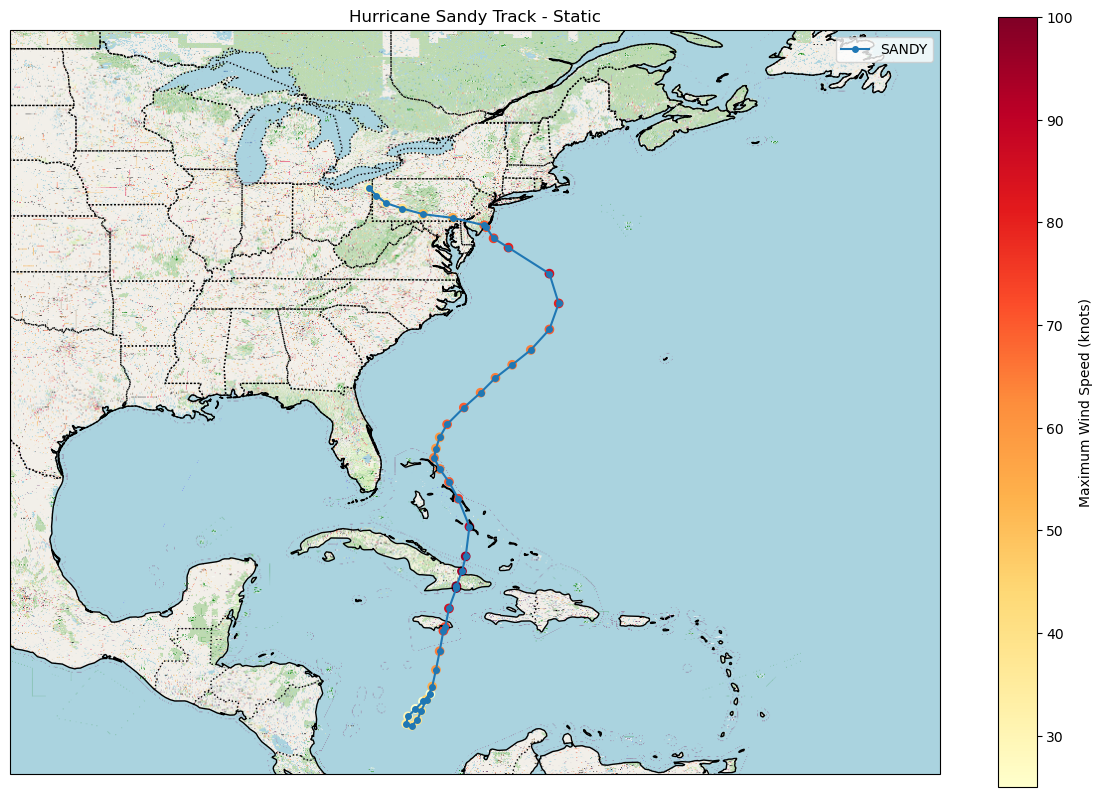

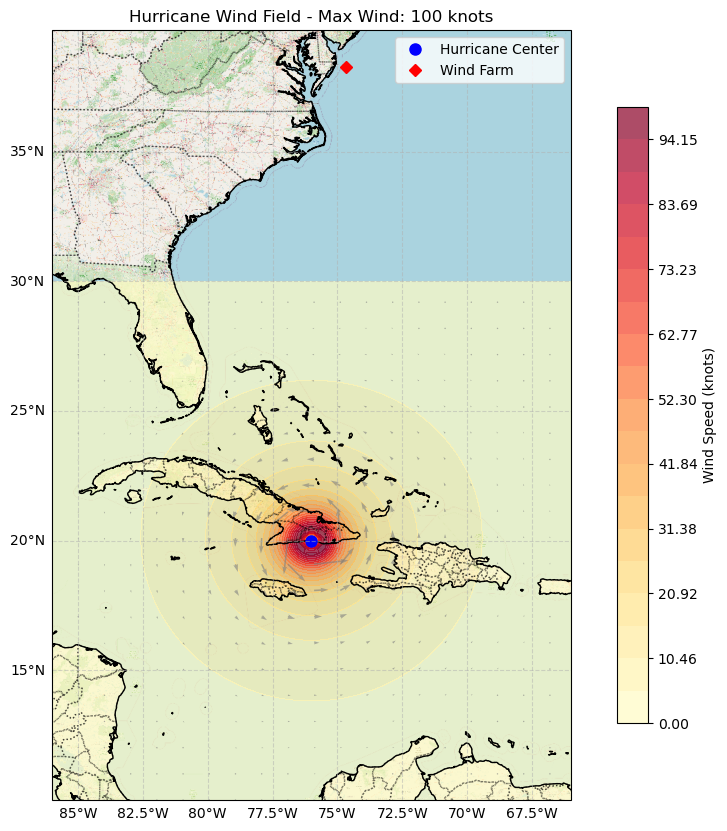

Hurricane report generated and saved to /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Response_hurricane/Output_maps_lite/hurricane_sandy_report.csv

=== HURRICANE SUMMARY ===
Hurricane: SANDY (AL182012)
Duration: 2012-10-21 18:00:00 to 2012-10-31 12:00:00
Closest approach: 83.5 km
Maximum wind at farm: 86.8 knots
Peak hurricane intensity: 100.0 knots


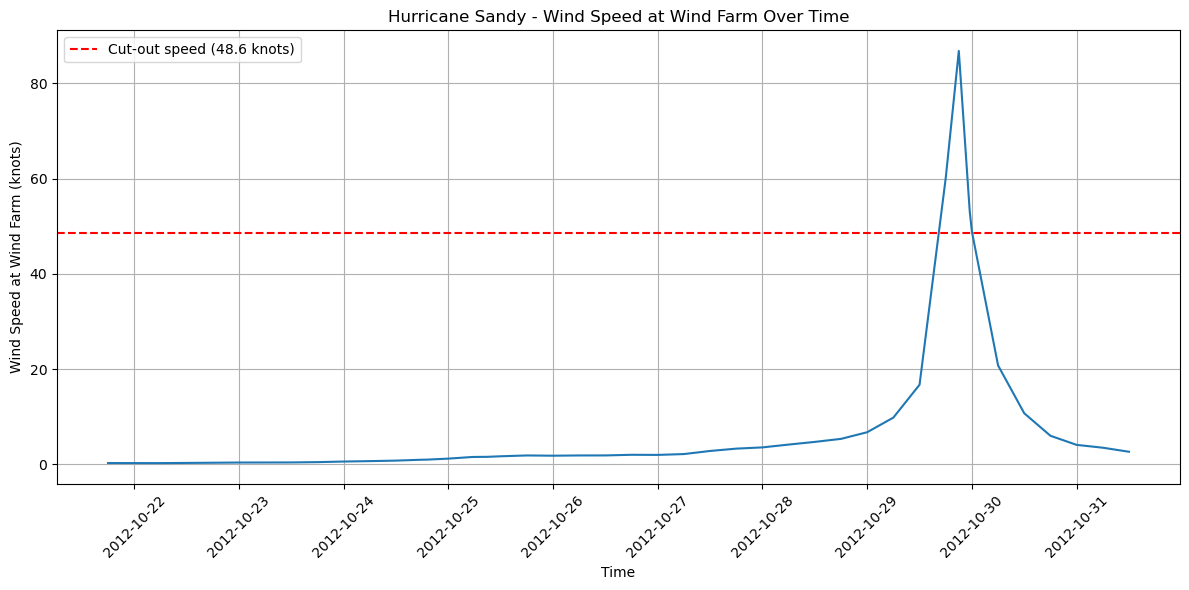


ALL FILES SAVED TO: /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Response_hurricane/Output_maps_lite
INTERACTIVE VIEWER:
  Main viewer: /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Response_hurricane/Output_maps_lite/hurricane_sandy_interactive_viewer.html
  Features: Toggle between stages, real-time status updates

INDIVIDUAL SNAPSHOTS:
  Stage 1: /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Response_hurricane/Output_maps_lite/hurricane_sandy_stage_1_start.html
  Stage 2: /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Response_hurricane/Output_maps_lite/hurricane_sandy_stage_2_approaching_stage_1.html
  Stage 3: /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Response_hurricane/Output_maps_lite/hurricane_sandy_stage_3_appro

In [8]:
# Initialize the hurricane simulation with coordinate files and output directory
output_directory = "/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Digital_Twin/Response_hurricane/Output_maps_lite"

hurricane_sim = HurricaneSimulation(
    hurdat2_file, 
    wind_farm_lat, 
    wind_farm_lon, 
    turbines_coord=turbines_coord,
    windfarm_coord=windfarm_coord,
    output_dir=output_directory
)

# Example: Select Hurricane Sandy (2012)
sandy_data = hurricane_sim.select_hurricane('AL182012')

# Calculate wind speeds over time for the wind farm location
sandy_with_winds = hurricane_sim.estimate_wind_speed_over_time(sandy_data)

# Create interactive progression viewer
print("Creating interactive hurricane progression viewer...")
viewer_html, map_files = hurricane_sim.create_interactive_progression_viewer(
    sandy_with_winds, 
    title='Hurricane Sandy Progression',
    cut_out_distance=300  # Distance at which wind farm shuts down (km)
)

# Save the interactive viewer
viewer_filename = os.path.join(output_directory, 'hurricane_sandy_interactive_viewer.html')
with open(viewer_filename, 'w') as f:
    f.write(viewer_html)

print(f"Interactive viewer saved to: {viewer_filename}")
print(f"Individual map files saved to: {output_directory}")

# Display the interactive viewer
from IPython.display import IFrame, display
try:
    display(IFrame(viewer_filename, width=1000, height=800))
except:
    print(f"Please open {viewer_filename} in your browser to view the interactive progression")

# Also create individual snapshots for backup
print("\nCreating individual snapshots...")
progression_maps = hurricane_sim.plot_hurricane_progression_snapshots(
    sandy_with_winds, 
    title='Hurricane Sandy Progression',
    cut_out_distance=300
)

# Save individual snapshots
for i, (map_obj, stage_name, datetime_str, distance, is_shutdown) in enumerate(progression_maps):
    filename = f'hurricane_sandy_stage_{i+1}_{stage_name.lower().replace(" ", "_").replace("(", "").replace(")", "")}.html'
    filepath = os.path.join(output_directory, filename)
    map_obj.save(filepath)
    
    print(f"Stage {i+1} ({stage_name}): {filepath}")
    print(f"  Time: {datetime_str}")
    print(f"  Distance: {distance:.1f} km")
    print(f"  Status: {'SHUTDOWN' if is_shutdown else 'OPERATIONAL'}")

# Create comprehensive maps
print("\n" + "="*60)
print("Creating comprehensive hurricane track and wind field maps...")

track_map = hurricane_sim.plot_hurricane_tracks_folium(sandy_with_winds, 'Hurricane Sandy Complete Track')
track_filepath = os.path.join(output_directory, 'hurricane_sandy_complete_track.html')
track_map.save(track_filepath)

peak_intensity_idx = sandy_with_winds['max_wind'].idxmax()
peak_data = sandy_with_winds.loc[peak_intensity_idx]
wind_map = hurricane_sim.plot_wind_field_folium(peak_data, rmax=50, B=1.5)
wind_filepath = os.path.join(output_directory, 'hurricane_sandy_wind_field.html')
wind_map.save(wind_filepath)

# Create static matplotlib plots
print("\nCreating static matplotlib plots...")
hurricane_sim.plot_hurricane_tracks(sandy_with_winds, 'Hurricane Sandy Track - Static')
hurricane_sim.plot_wind_field(peak_data, rmax=50, B=1.5, show_vectors=True)

# Generate hurricane report
hurricane_sim.generate_hurricane_report(
    sandy_with_winds, 
    output_file='hurricane_sandy_report.csv',
    cut_out_speed=48.6,
    arrival_distance_threshold=500
)

# Display summary statistics
print("\n=== HURRICANE SUMMARY ===")
print(f"Hurricane: {sandy_with_winds['storm_name'].iloc[0]} ({sandy_with_winds['full_id'].iloc[0]})")
print(f"Duration: {sandy_with_winds['datetime'].min()} to {sandy_with_winds['datetime'].max()}")
print(f"Closest approach: {sandy_with_winds['distance_km'].min():.1f} km")
print(f"Maximum wind at farm: {sandy_with_winds['wind_speed'].max():.1f} knots")
print(f"Peak hurricane intensity: {sandy_with_winds['max_wind'].max():.1f} knots")

# Show wind speed time series
plt.figure(figsize=(12, 6))
plt.plot(sandy_with_winds['datetime'], sandy_with_winds['wind_speed'])
plt.axhline(y=48.6, color='r', linestyle='--', label='Cut-out speed (48.6 knots)')
plt.xlabel('Time')
plt.ylabel('Wind Speed at Wind Farm (knots)')
plt.title('Hurricane Sandy - Wind Speed at Wind Farm Over Time')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Instructions
print("\n" + "="*60)
print("ALL FILES SAVED TO:", output_directory)
print("INTERACTIVE VIEWER:")
print(f"  Main viewer: {viewer_filename}")
print("  Features: Toggle between stages, real-time status updates")
print("\nINDIVIDUAL SNAPSHOTS:")
for i, (_, stage_name, _, _, _) in enumerate(progression_maps):
    filename = f'hurricane_sandy_stage_{i+1}_{stage_name.lower().replace(" ", "_").replace("(", "").replace(")", "")}.html'
    print(f"  Stage {i+1}: {os.path.join(output_directory, filename)}")
print("\nCOMPREHENSIVE MAPS:")
print(f"  Complete track: {track_filepath}")
print(f"  Wind field: {wind_filepath}")
print("="*60)